In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ModuleNotFoundError: No module named 'seaborn'

In [2]:
data = pd.read_csv("D:\AI learning notes\machine_learning\ex1-linear regression\ex1data1.txt", names = ["人口", "利润"])

d:\Anaconda\envs\pytorch\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\envs\pytorch\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 21475 (\N{CJK UNIFIED IDEOGRAPH-53E3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\envs\pytorch\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 21033 (\N{CJK UNIFIED IDEOGRAPH-5229}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\envs\pytorch\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 28070 (\N{CJK UNIFIED IDEOGRAPH-6DA6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


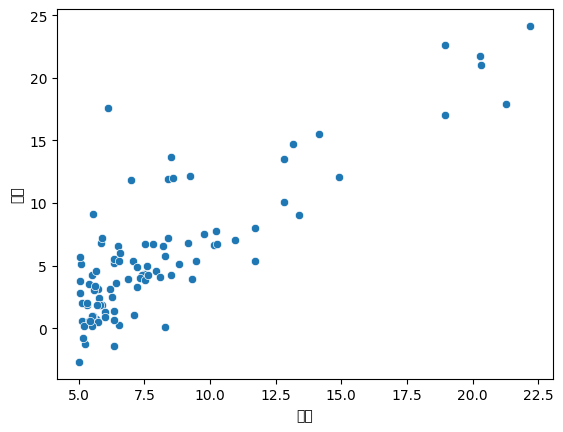

In [3]:
sns.scatterplot(data= data, x='人口', y='利润')
plt.show()

In [4]:
dt = torch.tensor(data.to_numpy(), dtype = torch.float32)    #dt : data_tensor
print(dt)

tensor([[ 6.1101, 17.5920],
        [ 5.5277,  9.1302],
        [ 8.5186, 13.6620],
        [ 7.0032, 11.8540],
        [ 5.8598,  6.8233],
        [ 8.3829, 11.8860],
        [ 7.4764,  4.3483],
        [ 8.5781, 12.0000],
        [ 6.4862,  6.5987],
        [ 5.0546,  3.8166],
        [ 5.7107,  3.2522],
        [14.1640, 15.5050],
        [ 5.7340,  3.1551],
        [ 8.4084,  7.2258],
        [ 5.6407,  0.7162],
        [ 5.3794,  3.5129],
        [ 6.3654,  5.3048],
        [ 5.1301,  0.5608],
        [ 6.4296,  3.6518],
        [ 7.0708,  5.3893],
        [ 6.1891,  3.1386],
        [20.2700, 21.7670],
        [ 5.4901,  4.2630],
        [ 6.3261,  5.1875],
        [ 5.5649,  3.0825],
        [18.9450, 22.6380],
        [12.8280, 13.5010],
        [10.9570,  7.0467],
        [13.1760, 14.6920],
        [22.2030, 24.1470],
        [ 5.2524, -1.2200],
        [ 6.5894,  5.9966],
        [ 9.2482, 12.1340],
        [ 5.8918,  1.8495],
        [ 8.2111,  6.5426],
        [ 7.9334,  4

损失函数
$$J\left( w, b \right)=\frac{1}{2m}\sum\limits_{i=1}^{m}{{{\left( {{h}_{w }}\left( {{x}^{(i)}} \right)-{{y}^{(i)}} \right)}^{2}}}$$
其中，对线性回归：
$$
h_w(x) = w x + b
$$

In [5]:
# 线性回归的损失函数(x为一维)

def loss_function_D1(x, y, w, b):
    y_hat = w * x + b
    loss = ((y_hat - y) ** 2).mean()
    return loss

# 梯度下降求解最优参数

def gradient_descent_D1(x, y, w, b, steps=500, alpha=0.03):
    """
    执行梯度下降优化 w 和 b
    """
    for i in range(steps):
        # 前向计算损失
        loss = loss_function_D1(x, y, w, b)
        
        # 反向传播
        loss.backward()
        
        with torch.no_grad():
            w -= alpha * w.grad
            b -= alpha * b.grad
        
        # 清零梯度
        w.grad.zero_()
        b.grad.zero_()
    
    return w, b

In [6]:
# 高维线性回归

def loss_function(x, y, w, b):
    y_hat = x @ w - b
    loss = ((y_hat - y)**2).mean()
    return loss

def gradient_descent(x, y, w,b, steps = 500, alpha = 0.02):

    for i in range(steps):
        loss = loss_function_D1(x ,y, w, b)
        loss.backward

        with torch.no_grad():
            w = alpha * w.grad
            b = alpha * b.grad
        
        w.grad.zero_()
        b.grad.zero_()

    return w,b

In [8]:
x = torch.tensor([1.0, 2.0, 3.0, 4.0, 5.0])
y = torch.tensor([3.0, 5.0, 7.0, 9.0, 11.0])
# 真实情况：y = 2x + 1, 即 w = 2, b = 1

# 对需要求导的参数添加梯度
w = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)  

a = gradient_descent_D1(x, y ,w ,b)
w = a[0]
b = a[1]
print(w)
print(b)

tensor(2.0011, requires_grad=True)
tensor(0.9959, requires_grad=True)
